<a href="https://colab.research.google.com/github/Marco-Merini/AtividadeN2-p1_Mineracao/blob/main/Atividade_N2_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTÃO 1

In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV
file_name = 'sfo 2018_data file_final_Weightedv2(DATA).csv'
df = pd.read_csv(file_name, sep=';', encoding='latin1')  # Use 'latin1' ou 'utf-8' se houver problemas com caracteres especiais

# Visualizar as primeiras linhas
print(df.head())

   RESPNUM  CCGID RUNID  INTDATE  DAY  GATE BAREA  STRATA  PEAK  METH  ...  \
0     1842   1680   552       21    2   102     G       3     3     1  ...   
1     1844   1681   552       21    2   102     G       3     3     1  ...   
2     1840   1678   552       21    2   102     G       3     3     1  ...   
3     1837   1676   552       21    2   102     G       3     3     1  ...   
4     1833   1674   552       21    2   102     G       3     3     1  ...   

   HOME Q19Clear Q20Age  Q21Gender  Q22Income  Q23FLY  Q24SJC  Q24OAK LANG  \
0    15        2      6          2          0       0       2       2    1   
1    15        2      4          1          2       1       2       2    1   
2    15        1      5          1          5       2       2       2    1   
3    15        2      2          2          3       3       2       1    1   
4    15        2      2          2          2       2       2       2    1   

      WEIGHT  
0  0,6704842  
1  0,6704842  
2  0,6704842  
3 

Colunas disponíveis no DataFrame:
['RESPNUM', 'CCGID', 'RUNID', 'INTDATE', 'DAY', 'GATE', 'BAREA', 'STRATA', 'PEAK', 'METH', 'SAQ', 'AIRLINE', 'DESTINATION', 'FLIGHT', 'AIRLINE_CODE', 'DEST_CODE', 'DESTGEO', 'DESTMARK', 'ARRTIME', 'DEPTIME', 'HOWLONG', 'Q2PURP1', 'Q2PURP2', 'Q2PURP3', 'Q3GETTO1', 'Q3GETTO2', 'Q3GETTO3', 'Q3PARK', 'Q4BAGS', 'Q4STORE', 'Q4FOOD', 'Q4WIFI', 'Q5TIMESFLOWN', 'Q5FIRSTTIME', 'Q6LONGUSE', 'Q7ART', 'Q7FOOD', 'Q7STORE', 'Q7SIGN', 'Q7WALKWAY', 'Q7SCREENS', 'Q7INFODOWN', 'Q7INFOUP', 'Q7WIFI', 'Q7ROADS', 'Q7PARK', 'Q7AIRTRAIN', 'Q7LTPARKING', 'Q7RENTAL', 'Q7ALL', 'Q8-1', 'Q8-2', 'Q8-3', 'Q8-4', 'Q8-5', 'Q8-6', 'Q9Boarding', 'Q9AirTrain', 'Q9Rental', 'Q9Food', 'Q9Restroom', 'Q9All', 'Q9-1', 'Q9-2', 'Q9-3', 'Q10Safe', 'Q10-1', 'Q10-2', 'Q10-3', 'Q11TSAPRE', 'Q12PRECHECKRATE', 'Q12-1', 'Q12-2', 'Q12-3', 'Q13COUNTY', 'Q13GETRATE', 'Q14FIND ', 'Q14PASSTHRU', 'Q15PROBLEM', 'Q15A', 'Q15-1', 'Q15-2', 'Q15-3', 'NETPRO  ', 'Q17LIVE', 'Q18CITY', 'Q18COUNTY', 'Q18STATE', 'Q18ZI

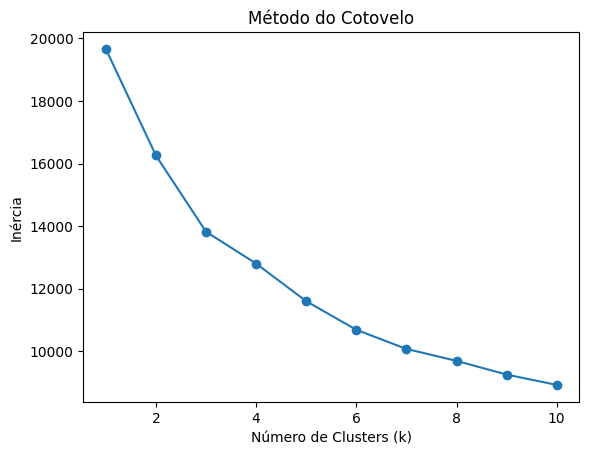


Tamanho dos Clusters (%):
Cluster
0    49.412602
1    43.325027
2     7.262371
Name: proportion, dtype: float64

Perfil Médio dos Clusters:
         NETPRO      Q20Age  Q21Gender  Q22Income    Q23FLY  Q5TIMESFLOWN  \
Cluster                                                                     
0        8.318444  4.857349   1.515850   2.753602  1.876081      2.884006   
1        7.923583  3.601479   1.543139   1.560394  2.019721      1.493016   
2        9.529412  1.171569   0.426471   0.142157  0.205882      2.362745   

         Q6LONGUSE  
Cluster             
0         3.533862  
1         1.464256  
2         2.534314  

Cluster Incomum: 2
Tamanho: 7.26%

Perfil do Cluster Incomum:
NETPRO          9.529412
Q20Age          1.171569
Q21Gender       0.426471
Q22Income       0.142157
Q23FLY          0.205882
Q5TIMESFLOWN    2.362745
Q6LONGUSE       2.534314
Name: 2, dtype: float64


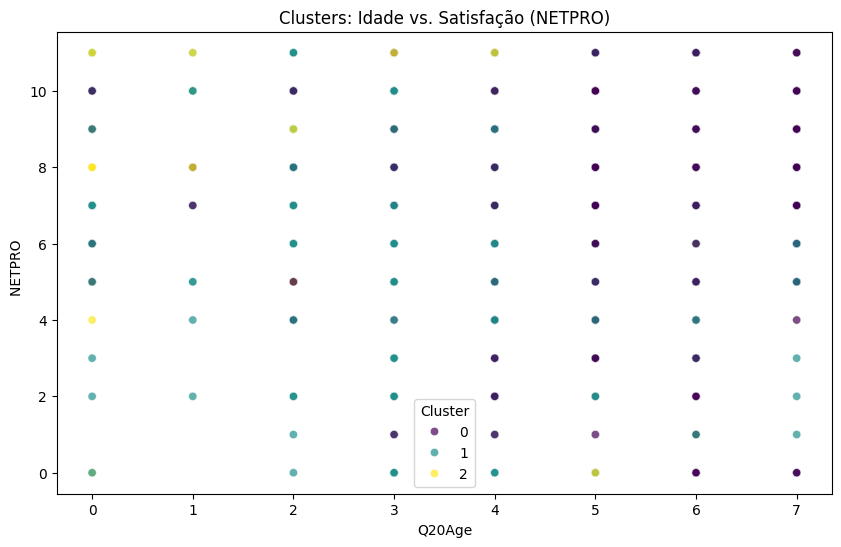

In [27]:
# Carregar os dados
file_name = 'sfo 2018_data file_final_Weightedv2(DATA).csv'
df = pd.read_csv(file_name, sep=';', encoding='latin1')

# Verificar colunas disponíveis (para debug)
print("Colunas disponíveis no DataFrame:")
print(df.columns.tolist())

# Selecionar variáveis relevantes (ajustar conforme os nomes reais)
# Exemplo: se 'NETPRO' estiver como 'NETPRO  ' ou outro nome
features = ['NETPRO  ', 'Q20Age', 'Q21Gender', 'Q22Income', 'Q23FLY', 'Q5TIMESFLOWN', 'Q6LONGUSE']
# Ou, se 'NETPRO' não existir, substituir por outra variável de satisfação (ex: 'Q9All')

# Verificar se as colunas existem no DataFrame
features = [col for col in features if col in df.columns]
if not features:
    raise KeyError("Nenhuma das colunas selecionadas existe no DataFrame.")

df_cluster = df[features].copy()

# Tratar valores ausentes e inválidos (como 'BLANK')
df_cluster.replace('BLANK', np.nan, inplace=True)
df_cluster = df_cluster.dropna()  # Remover linhas com NaN

# Converter dados para numérico
df_cluster = df_cluster.apply(pd.to_numeric, errors='coerce').dropna()

# Padronizar os dados (importante para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Método do Cotovelo para escolher o número de clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

# Escolher k=3 (exemplo) e aplicar K-Means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar os clusters ao DataFrame
df_cluster['Cluster'] = clusters

# Tamanho dos clusters (em %)
cluster_sizes = df_cluster['Cluster'].value_counts(normalize=True) * 100
print("\nTamanho dos Clusters (%):")
print(cluster_sizes)

# Perfil médio de cada cluster
cluster_profile = df_cluster.groupby('Cluster').mean()
print("\nPerfil Médio dos Clusters:")
print(cluster_profile)

# Identificar o cluster incomum (menor % ou características distintas)
unusual_cluster = cluster_sizes.idxmin()  # Pega o cluster com menor %
print(f"\nCluster Incomum: {unusual_cluster}")
print(f"Tamanho: {cluster_sizes[unusual_cluster]:.2f}%")
print("\nPerfil do Cluster Incomum:")
print(cluster_profile.loc[unusual_cluster])

# Visualização (exemplo: idade vs. satisfação)
if 'Q20Age' in df_cluster.columns and 'NETPRO  ' in df_cluster.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_cluster,
        x='Q20Age',
        y='NETPRO  ',
        hue='Cluster',
        palette='viridis',
        alpha=0.7
    )
    plt.title('Clusters: Idade vs. Satisfação (NETPRO)')
    plt.show()
else:
    print("\nAviso: 'Q20Age' ou 'NETPRO  ' não estão disponíveis para visualização.")


QUESTÃO 2

In [33]:
# 1. Upload do CSV
from google.colab import files
uploaded = files.upload()

Saving Sales Data.csv to Sales Data.csv


In [34]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV
file_name = 'Sales Data.csv'
df = pd.read_csv(file_name, sep=';', encoding='latin1')  # Use 'latin1' ou 'utf-8' se houver problemas com caracteres especiais

# Visualizar as primeiras linhas
print(df.head())

  ,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0  0,295665,Macbook Pro Laptop,1,1700.0,2019-12-3...                                             
1  1,295666,LG Washing Machine,1,600.0,2019-12-29...                                             
2  2,295667,USB-C Charging Cable,1,11.95,2019-12-...                                             
3  3,295668,27in FHD Monitor,1,149.99,2019-12-22 ...                                             
4  4,295669,USB-C Charging Cable,1,11.95,2019-12-...                                             


Saving Sales Data.csv to Sales Data (3).csv

Itemsets frequentes encontrados: 54

Top 10 Itemsets mais frequentes:
     support                              itemsets
0   0.295228                (USB-C Charging Cable)
7   0.272834                              (iPhone)
8   0.252049            (Lightning Charging Cable)
5   0.239022                        (Google Phone)
1   0.234924                    (Wired Headphones)
44  0.147980    (Lightning Charging Cable, iPhone)
37  0.145931  (Google Phone, USB-C Charging Cable)
2   0.135539            (Apple Airpods Headphones)
6   0.112119          (Bose SoundSport Headphones)
10  0.105240              (AAA Batteries (4-pack))

Top 20 Regras de Associação:
                                             antecedents  \
16                            (Lightning Charging Cable)   
17                                              (iPhone)   
11                                     (Vareebadd Phone)   
12                                        (Google Phon

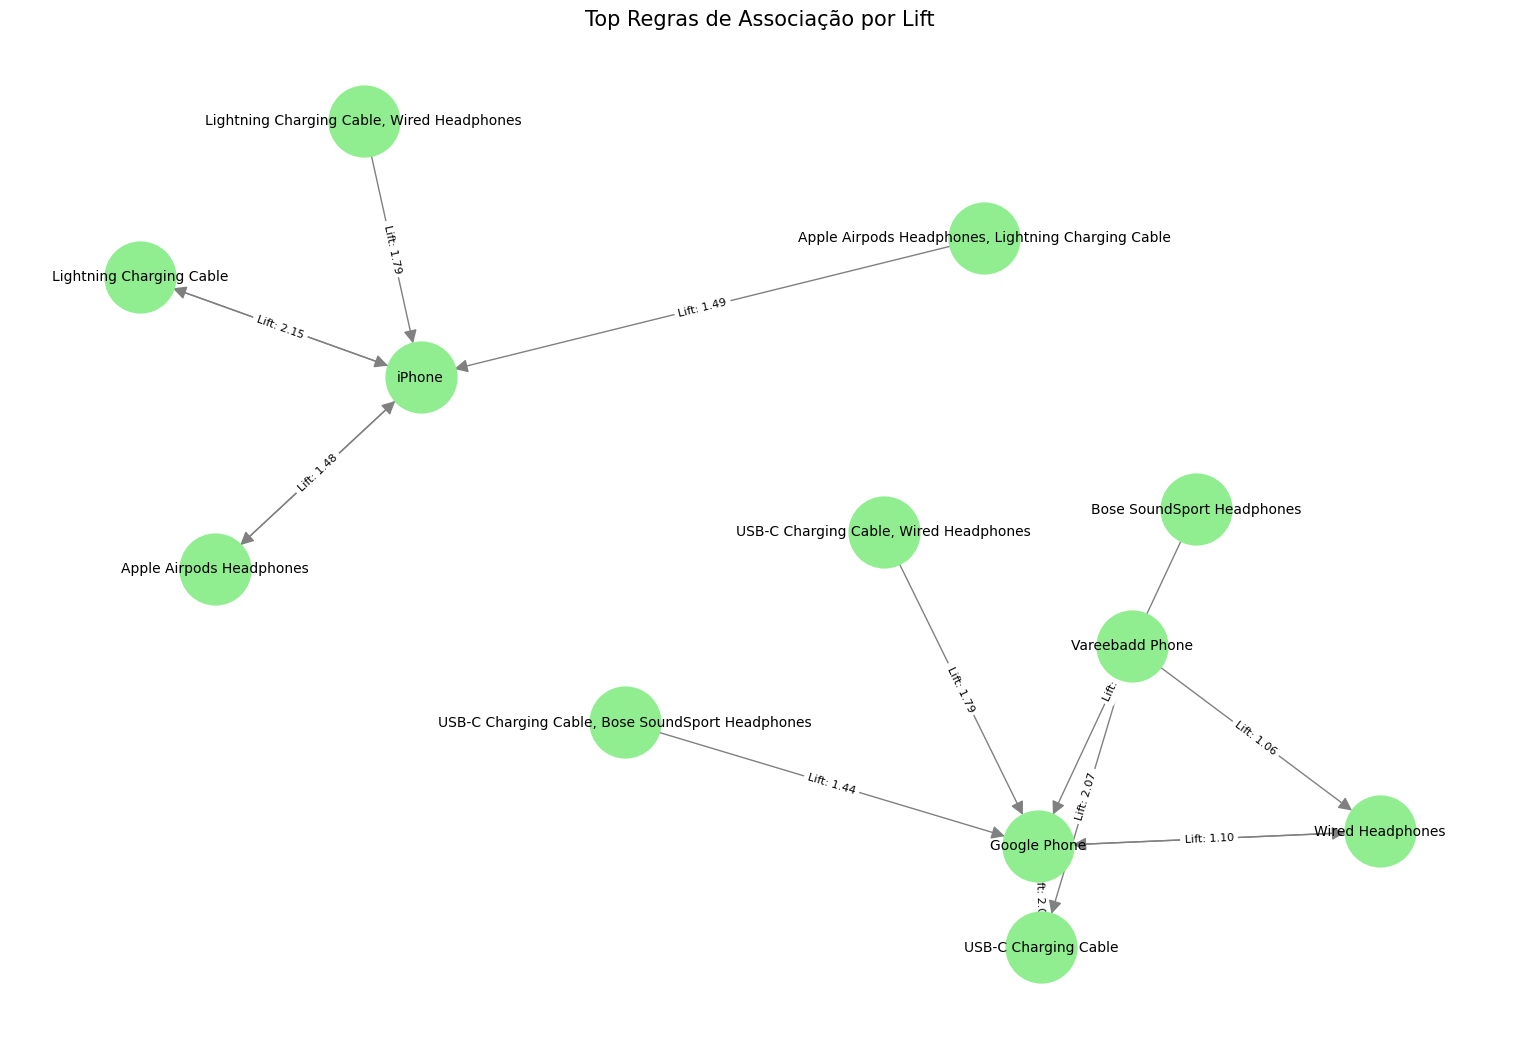


Estatísticas dos dados:
Total de transações: 6832
Total de produtos únicos: 19

Produtos mais vendidos:
Product
USB-C Charging Cable          21855
Lightning Charging Cable      21604
AAA Batteries (4-pack)        20593
AA Batteries (4-pack)         20542
Wired Headphones              18847
Apple Airpods Headphones      15525
Bose SoundSport Headphones    13298
27in FHD Monitor               7498
iPhone                         6840
27in 4K Gaming Monitor         6225
Name: count, dtype: int64


In [37]:
# Instalação de bibliotecas necessárias
!pip install pyfpgrowth pandas mlxtend

import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Carregar os dados
from google.colab import files
uploaded = files.upload()

# Ler o arquivo CSV
df = pd.read_csv(next(iter(uploaded.keys())))

# Pré-processamento avançado
# 1. Remover duplicatas exatas na mesma ordem
df = df.drop_duplicates(subset=['Order ID', 'Product'])

# 2. Agrupar produtos por Order ID
transactions = df.groupby('Order ID')['Product'].apply(list).reset_index(name='Items')

# 3. Filtrar transações com pelo menos 2 itens
transactions['Count'] = transactions['Items'].apply(len)
transactions = transactions[transactions['Count'] >= 2]

# Converter para lista de listas
transaction_list = transactions['Items'].tolist()

# Codificar as transações
te = TransactionEncoder()
te_ary = te.fit(transaction_list).transform(transaction_list)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Parâmetros otimizados
min_support = 0.005  # 0.5% de suporte mínimo
min_confidence = 0.2  # 20% de confiança mínima

# Aplicar FP-Growth
frequent_itemsets = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)

# Gerar regras de associação
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="confidence",
                            min_threshold=min_confidence)
    rules = rules.sort_values(by='lift', ascending=False)

    # Filtrar regras relevantes (lift > 1)
    relevant_rules = rules[rules['lift'] > 1]

    # Mostrar resultados
    print("\nItemsets frequentes encontrados:", len(frequent_itemsets))
    print("\nTop 10 Itemsets mais frequentes:")
    print(frequent_itemsets.sort_values('support', ascending=False).head(10))

    if not relevant_rules.empty:
        print("\nTop 20 Regras de Associação:")
        pd.set_option('display.max_colwidth', 100)
        print(relevant_rules[['antecedents', 'consequents', 'support',
                            'confidence', 'lift']].head(20))

        # Visualização gráfica
        import matplotlib.pyplot as plt
        import networkx as nx

        plt.figure(figsize=(15, 10))
        G = nx.DiGraph()

        for _, row in relevant_rules.head(15).iterrows():
            G.add_edge(", ".join(list(row['antecedents'])),
                      ", ".join(list(row['consequents'])),
                      weight=row['lift'])

        pos = nx.spring_layout(G, k=0.8, iterations=50)
        nx.draw(G, pos, with_labels=True,
                node_color='lightgreen',
                node_size=2500,
                edge_color='gray',
                linewidths=2,
                font_size=10,
                arrowsize=20)

        edge_labels = {(u, v): f"Lift: {d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

        plt.title("Top Regras de Associação por Lift", fontsize=15)
        plt.show()
    else:
        print("\nNenhuma regra relevante encontrada (lift > 1).")
else:
    print("\nNenhum itemset frequente encontrado com suporte mínimo de", min_support)

# Análise complementar
print("\nEstatísticas dos dados:")
print("Total de transações:", len(transactions))
print("Total de produtos únicos:", len(df['Product'].unique()))
print("\nProdutos mais vendidos:")
print(df['Product'].value_counts().head(10))

QUESTÃO 3

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Carregar os dados
df = pd.read_csv('Sales Data.csv')

# Pré-processamento
# Criar variável target: 1 se comprou produto caro (>500), 0 caso contrário
df['high_value_purchase'] = np.where(df['Price Each'] * df['Quantity Ordered'] > 500, 1, 0)

# Selecionar features relevantes
features = ['Quantity Ordered', 'Hour', 'Month']
X = df[features]
y = df['high_value_purchase']

# Tratar valores missing (se houver)
X = X.fillna(X.mean())

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar os dados (importante para regressão logística)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
# Criar e treinar o modelo de regressão logística
model = LogisticRegression()
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

In [40]:
# Avaliar o modelo
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Coeficientes do modelo
print("\nCoeficientes do modelo:")
for feature, coef in zip(features, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Acurácia: 0.8776732096441696

Matriz de Confusão:
[[48961     0]
 [ 6824     0]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     48961
           1       0.00      0.00      0.00      6824

    accuracy                           0.88     55785
   macro avg       0.44      0.50      0.47     55785
weighted avg       0.77      0.88      0.82     55785


Coeficientes do modelo:
Quantity Ordered: -1.3912
Hour: 0.0037
Month: -0.0181


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Distribuição das classes:
high_value_purchase
0    0.878543
1    0.121457
Name: proportion, dtype: float64

Aplicando SMOTE para balancear as classes...

Distribuição após SMOTE:
high_value_purchase
0    114355
1    114355
Name: count, dtype: int64

Treinando o modelo com parâmetros ajustados...

=== Métricas de Avaliação ===
Acurácia: 0.9995
AUC-ROC: 0.9999

Matriz de Confusão:


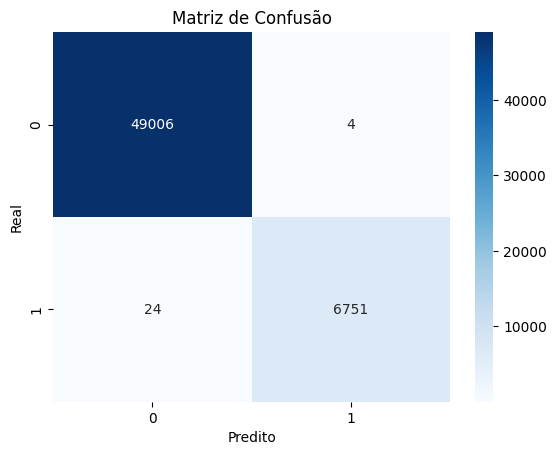


Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49010
           1       1.00      1.00      1.00      6775

    accuracy                           1.00     55785
   macro avg       1.00      1.00      1.00     55785
weighted avg       1.00      1.00      1.00     55785


Coeficientes do Modelo:
                Feature  Coeficiente
1            Price Each    18.154443
11  City_ San Francisco     1.483545
8     City_ Los Angeles     1.187394
9   City_ New York City     1.122690
6          City_ Boston     1.075874
4         City_ Atlanta     0.947234
12        City_ Seattle     0.901361
0      Quantity Ordered     0.896375
7          City_ Dallas     0.879403
10       City_ Portland     0.817691
5          City_ Austin     0.700688
2                  Hour    -0.015911
3                 Month    -0.036750


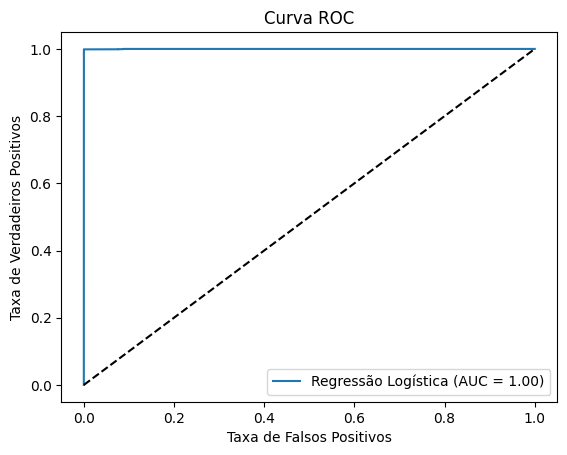


Treinando Random Forest para comparação...

Acurácia (Random Forest): 0.8785515819664784
Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     49010
           1       0.00      0.00      0.00      6775

    accuracy                           0.88     55785
   macro avg       0.44      0.50      0.47     55785
weighted avg       0.77      0.88      0.82     55785



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar e preparar os dados
df = pd.read_csv('Sales Data.csv')

# Criar variável target (1 para compras > $500, 0 caso contrário)
df['high_value_purchase'] = np.where(df['Price Each'] * df['Quantity Ordered'] > 500, 1, 0)

# Verificar distribuição das classes
print("Distribuição das classes:")
print(df['high_value_purchase'].value_counts(normalize=True))

# Selecionar features - vamos adicionar mais variáveis relevantes
features = ['Quantity Ordered', 'Price Each', 'Hour', 'Month', 'City']
X = pd.get_dummies(df[features], columns=['City'])  # One-hot encoding para cidades
y = df['high_value_purchase']

# 2. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Balanceamento das classes com SMOTE
print("\nAplicando SMOTE para balancear as classes...")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("\nDistribuição após SMOTE:")
print(pd.Series(y_res).value_counts())

# 4. Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# 5. Treinar o modelo ajustado
print("\nTreinando o modelo com parâmetros ajustados...")
model = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
model.fit(X_train_scaled, y_res)

# 6. Avaliação do modelo
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Métricas de Avaliação ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

print("\nMatriz de Confusão:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 7. Análise dos coeficientes
print("\nCoeficientes do Modelo:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_[0]
})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)
print(coef_df)

# 8. Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label='Regressão Logística (AUC = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# 9. Opcional: Random Forest para comparação
from sklearn.ensemble import RandomForestClassifier
print("\nTreinando Random Forest para comparação...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_res, y_res)

y_pred_rf = rf_model.predict(X_test_scaled)
print("\nAcurácia (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("Relatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_rf))